# 01 - EDA & Preprocessing
## CICDDoS2019 Multi-Class DDoS Detection

**Strategi:** Load per file menggunakan chunks, lalu stratified sample per label.
Ini menjaga proporsi asli benign vs attack sambil hemat memory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import pickle
import warnings
import gc
warnings.filterwarnings('ignore')

# CONFIG
MAX_ROWS_PER_FILE = 100000   # max rows to keep per CSV file
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
print('Libraries imported OK')
print(f'Strategy: stratified sample, max {MAX_ROWS_PER_FILE:,} rows per file')

Libraries imported OK
Strategy: stratified sample, max 30,000 rows per file


## 1. Load Training Day (01-12) — Stratified Sampling

In [2]:
TRAIN_DIR = '../data/CIC-DDoS2019-Dataset/01-12/'
TEST_DIR = '../data/CIC-DDoS2019-Dataset/03-11/'

train_files = sorted(glob.glob(os.path.join(TRAIN_DIR, '*.csv')))
print(f'Training files: {len(train_files)}')
for f in train_files:
    print(f'  {os.path.basename(f):30s} ({os.path.getsize(f)/(1024*1024):.1f} MB)')

Training files: 11
  DrDoS_DNS.csv                  (2034.5 MB)
  DrDoS_LDAP.csv                 (874.8 MB)
  DrDoS_MSSQL.csv                (1801.7 MB)
  DrDoS_NTP.csv                  (615.1 MB)
  DrDoS_NetBIOS.csv              (1618.8 MB)
  DrDoS_SNMP.csv                 (2071.9 MB)
  DrDoS_SSDP.csv                 (1194.7 MB)
  DrDoS_UDP.csv                  (1436.3 MB)
  Syn.csv                        (607.8 MB)
  TFTP.csv                       (8871.1 MB)
  UDPLag.csv                     (150.7 MB)


In [3]:
def load_and_sample(filepath, max_rows=30000, seed=42):
    """
    Load CSV using chunks, then stratified sample per label.
    Keeps original benign/attack ratio within the sample.
    """
    fname = os.path.basename(filepath)
    
    # Read in chunks to avoid OOM
    chunks = []
    chunk_size = 50000
    total_read = 0
    
    try:
        for chunk in pd.read_csv(filepath, chunksize=chunk_size, 
                                  low_memory=False, encoding='utf-8',
                                  on_bad_lines='skip'):
            chunks.append(chunk)
            total_read += len(chunk)
            # Stop early if we have enough for sampling
            if total_read >= max_rows * 3:
                break
    except Exception as e:
        print(f'  Error reading {fname}: {e}')
        return None
    
    df = pd.concat(chunks, ignore_index=True)
    df.columns = df.columns.str.strip()
    
    # Find label column
    label_col = [c for c in df.columns if 'label' in c.lower()]
    LABEL = label_col[0] if label_col else df.columns[-1]
    
    # Stratified sample: keep ratio per label
    if len(df) > max_rows:
        # Calculate proportional sample per class
        sampled_dfs = []
        for label_val, group in df.groupby(LABEL):
            proportion = len(group) / len(df)
            n_sample = max(1, int(max_rows * proportion))
            n_sample = min(n_sample, len(group))
            sampled_dfs.append(group.sample(n=n_sample, random_state=seed))
        df_sampled = pd.concat(sampled_dfs, ignore_index=True)
    else:
        df_sampled = df
    
    # Report
    label_dist = df_sampled[LABEL].value_counts().to_dict()
    print(f'  {fname:30s} | total read: {total_read:>8,} | sampled: {len(df_sampled):>6,} | labels: {label_dist}')
    
    # Free memory
    del df, chunks
    gc.collect()
    
    return df_sampled

In [4]:
print('Loading Training Day (stratified sampling)...')
print('-' * 80)

train_dfs = []
for f in train_files:
    result = load_and_sample(f, max_rows=MAX_ROWS_PER_FILE, seed=RANDOM_SEED)
    if result is not None:
        train_dfs.append(result)

df_train = pd.concat(train_dfs, ignore_index=True)
df_train.columns = df_train.columns.str.strip()
print(f'\nTotal Training: {len(df_train):,} rows, {df_train.shape[1]} cols')

# Free individual dfs
del train_dfs
gc.collect()

Loading Training Day (stratified sampling)...
--------------------------------------------------------------------------------
  DrDoS_DNS.csv                  | total read:  100,000 | sampled: 30,000 | labels: {'DrDoS_DNS': 29487, 'BENIGN': 513}
  DrDoS_LDAP.csv                 | total read:  100,000 | sampled: 30,000 | labels: {'DrDoS_LDAP': 29991, 'BENIGN': 9}
  DrDoS_MSSQL.csv                | total read:  100,000 | sampled: 29,999 | labels: {'DrDoS_MSSQL': 29804, 'BENIGN': 195}
  DrDoS_NTP.csv                  | total read:  100,000 | sampled: 29,999 | labels: {'DrDoS_NTP': 26239, 'BENIGN': 3760}
  DrDoS_NetBIOS.csv              | total read:  100,000 | sampled: 29,999 | labels: {'DrDoS_NetBIOS': 29827, 'BENIGN': 172}
  DrDoS_SNMP.csv                 | total read:  100,000 | sampled: 29,999 | labels: {'DrDoS_SNMP': 29986, 'BENIGN': 13}
  DrDoS_SSDP.csv                 | total read:  100,000 | sampled: 29,999 | labels: {'DrDoS_SSDP': 29965, 'BENIGN': 34}
  DrDoS_UDP.csv            

0

## 2. Load Testing Day (03-11) — Stratified Sampling

In [5]:
print('Loading Testing Day (stratified sampling)...')
print('-' * 80)

test_files = sorted(glob.glob(os.path.join(TEST_DIR, '*.csv')))

test_dfs = []
for f in test_files:
    result = load_and_sample(f, max_rows=MAX_ROWS_PER_FILE, seed=RANDOM_SEED)
    if result is not None:
        test_dfs.append(result)

df_test = pd.concat(test_dfs, ignore_index=True)
df_test.columns = df_test.columns.str.strip()
print(f'\nTotal Testing: {len(df_test):,} rows, {df_test.shape[1]} cols')

del test_dfs
gc.collect()

Loading Testing Day (stratified sampling)...
--------------------------------------------------------------------------------
  LDAP.csv                       | total read:  100,000 | sampled: 29,999 | labels: {'NetBIOS': 29972, 'BENIGN': 27}
  MSSQL.csv                      | total read:  100,000 | sampled: 29,999 | labels: {'MSSQL': 26898, 'LDAP': 2979, 'BENIGN': 122}
  NetBIOS.csv                    | total read:  100,000 | sampled: 29,999 | labels: {'NetBIOS': 29997, 'BENIGN': 2}
  Portmap.csv                    | total read:  100,000 | sampled: 29,999 | labels: {'Portmap': 28581, 'BENIGN': 1418}
  Syn.csv                        | total read:  100,000 | sampled: 29,999 | labels: {'Syn': 29993, 'BENIGN': 6}
  UDP.csv                        | total read:  100,000 | sampled: 29,999 | labels: {'UDP': 22191, 'MSSQL': 7317, 'BENIGN': 491}
  UDPLag.csv                     | total read:  100,000 | sampled: 29,999 | labels: {'UDP': 29968, 'BENIGN': 31}

Total Testing: 209,993 rows, 88 cols


0

## 3. EDA

In [6]:
# Find label column
label_col = [c for c in df_train.columns if 'label' in c.lower()]
LABEL = label_col[0] if label_col else df_train.columns[-1]
print(f'Label column: "{LABEL}"')

print(f'\n=== Training Labels ===')
print(df_train[LABEL].value_counts())
print(f'\n=== Testing Labels ===')
print(df_test[LABEL].value_counts())

Label column: "Label"

=== Training Labels ===
Label
TFTP             29996
Syn              29995
DrDoS_LDAP       29991
DrDoS_SNMP       29986
DrDoS_SSDP       29965
DrDoS_NetBIOS    29827
DrDoS_MSSQL      29804
DrDoS_UDP        29728
DrDoS_DNS        29487
UDP-lag          28773
DrDoS_NTP        26239
BENIGN            6076
WebDDoS            123
Name: count, dtype: int64

=== Testing Labels ===
Label
NetBIOS    59969
UDP        52159
MSSQL      34215
Syn        29993
Portmap    28581
LDAP        2979
BENIGN      2097
Name: count, dtype: int64


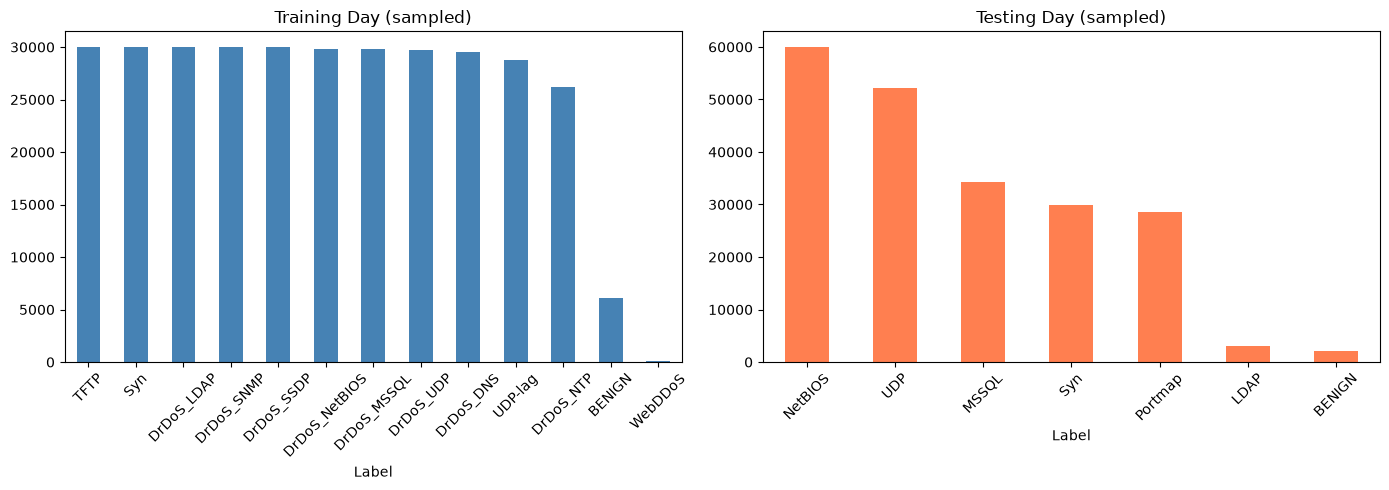

Saved: label_distribution.png


In [7]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_train[LABEL].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Training Day (sampled)')
axes[0].tick_params(axis='x', rotation=45)
df_test[LABEL].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Testing Day (sampled)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../data/label_distribution.png', dpi=150)
plt.show()
print('Saved: label_distribution.png')

## 4. Cleaning

In [8]:
def clean_dataset(df, label_col, name=''):
    print(f'\n--- Cleaning {name} ---')
    print(f'Before: {df.shape}')
    
    # Drop Timestamp
    ts_cols = [c for c in df.columns if 'timestamp' in c.lower()]
    if ts_cols:
        df = df.drop(columns=ts_cols)
        print(f'Dropped timestamp: {ts_cols}')
    
    # Separate X and y
    y = df[label_col].copy()
    X = df.drop(columns=[label_col])
    
    # Numeric only
    non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric:
        print(f'Dropped non-numeric: {non_numeric}')
    X = X.select_dtypes(include=[np.number])
    
    # Replace Inf, drop NaN
    X = X.replace([np.inf, -np.inf], np.nan)
    nan_count = X.isnull().any(axis=1).sum()
    print(f'Rows with NaN/Inf: {nan_count:,}')
    
    mask = ~X.isnull().any(axis=1)
    X = X[mask].reset_index(drop=True)
    y = y[mask].reset_index(drop=True)
    
    print(f'After: {X.shape[0]:,} rows, {X.shape[1]} features')
    return X, y

X_train, y_train = clean_dataset(df_train, LABEL, 'Training')
X_test, y_test = clean_dataset(df_test, LABEL, 'Testing')

# Free raw dataframes
del df_train, df_test
gc.collect()

# Align columns
common = sorted(set(X_train.columns) & set(X_test.columns))
X_train = X_train[common]
X_test = X_test[common]
print(f'\nCommon features: {len(common)}')


--- Cleaning Training ---
Before: (329990, 88)
Dropped timestamp: ['Timestamp']
Dropped non-numeric: ['Flow ID', 'Source IP', 'Destination IP', 'SimillarHTTP']
Rows with NaN/Inf: 10,704
After: 319,286 rows, 82 features

--- Cleaning Testing ---
Before: (209993, 88)
Dropped timestamp: ['Timestamp']
Dropped non-numeric: ['Flow ID', 'Source IP', 'Destination IP', 'SimillarHTTP']
Rows with NaN/Inf: 8,043
After: 201,950 rows, 82 features

Common features: 82


## 5. Label Standardization & Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder

def standardize(label):
    label = str(label).strip()
    if label.startswith('DrDoS_'):
        label = label.replace('DrDoS_', '')
    return label.upper()

y_train_std = y_train.apply(standardize)
y_test_std = y_test.apply(standardize)

print('=== Training labels (standardized) ===')
print(y_train_std.value_counts())
print(f'\n=== Testing labels (standardized) ===')
print(y_test_std.value_counts())

# Encode
le = LabelEncoder()
all_labels = sorted(set(y_train_std.unique()) | set(y_test_std.unique()))
le.fit(all_labels)

y_train_enc = le.transform(y_train_std)
y_test_enc = le.transform(y_test_std)

print(f'\nTotal classes: {len(le.classes_)}')
for i, c in enumerate(le.classes_):
    train_count = (y_train_enc == i).sum()
    test_count = (y_test_enc == i).sum()
    print(f'  {i:2d}: {c:15s} | train: {train_count:>6,} | test: {test_count:>6,}')

=== Training labels (standardized) ===
Label
SSDP       29613
SNMP       29500
UDP        29343
MSSQL      29232
LDAP       29225
NETBIOS    28716
DNS        28224
UDP-LAG    28096
TFTP       27681
SYN        27436
NTP        26058
BENIGN      6039
WEBDDOS      123
Name: count, dtype: int64

=== Testing labels (standardized) ===
Label
NETBIOS    56959
UDP        51891
MSSQL      32754
SYN        28233
PORTMAP    27057
LDAP        2978
BENIGN      2078
Name: count, dtype: int64

Total classes: 14
   0: BENIGN          | train:  6,039 | test:  2,078
   1: DNS             | train: 28,224 | test:      0
   2: LDAP            | train: 29,225 | test:  2,978
   3: MSSQL           | train: 29,232 | test: 32,754
   4: NETBIOS         | train: 28,716 | test: 56,959
   5: NTP             | train: 26,058 | test:      0
   6: PORTMAP         | train:      0 | test: 27,057
   7: SNMP            | train: 29,500 | test:      0
   8: SSDP            | train: 29,613 | test:      0
   9: SYN             

## 6. Save Cleaned Data

In [10]:
OUTPUT_DIR = '../data/'

train_data = {
    'X': X_train,
    'y': y_train_enc,
    'feature_names': list(X_train.columns),
    'label_encoder': le,
    'classes': list(le.classes_),
    'sampling_config': {
        'max_rows_per_file': MAX_ROWS_PER_FILE,
        'method': 'stratified_proportional',
        'seed': RANDOM_SEED
    }
}
test_data = {
    'X': X_test,
    'y': y_test_enc,
    'feature_names': list(X_test.columns),
    'label_encoder': le,
    'classes': list(le.classes_),
    'sampling_config': {
        'max_rows_per_file': MAX_ROWS_PER_FILE,
        'method': 'stratified_proportional',
        'seed': RANDOM_SEED
    }
}

with open(os.path.join(OUTPUT_DIR, 'cleaned_train.pkl'), 'wb') as f:
    pickle.dump(train_data, f)
with open(os.path.join(OUTPUT_DIR, 'cleaned_test.pkl'), 'wb') as f:
    pickle.dump(test_data, f)

print(f'Saved cleaned_train.pkl: {len(X_train):,} samples, {X_train.shape[1]} features')
print(f'Saved cleaned_test.pkl: {len(X_test):,} samples, {X_test.shape[1]} features')
print(f'\nClasses ({len(le.classes_)}): {list(le.classes_)}')
print(f'\n=== Done! Proceed to notebook 02. ===')

Saved cleaned_train.pkl: 319,286 samples, 82 features
Saved cleaned_test.pkl: 201,950 samples, 82 features

Classes (14): [np.str_('BENIGN'), np.str_('DNS'), np.str_('LDAP'), np.str_('MSSQL'), np.str_('NETBIOS'), np.str_('NTP'), np.str_('PORTMAP'), np.str_('SNMP'), np.str_('SSDP'), np.str_('SYN'), np.str_('TFTP'), np.str_('UDP'), np.str_('UDP-LAG'), np.str_('WEBDDOS')]

=== Done! Proceed to notebook 02. ===
